# Progressive Feature Selection for Parkinson's Disease Classification

**This notebook implements progressive feature selection using importance-based sequential removal.**

## Overview

This notebook explores how model performance changes as features are progressively removed based on importance:

1. **Start with all features** - Train baseline model and get feature importance
2. **Progressive removal** - Sequentially remove least important features (e.g., bottom 10-20% at each step)
3. **Sequential clustering** - Optionally cluster remaining features at each step
4. **Retrain and evaluate** - Train model on reduced feature set and track performance
5. **Performance tracking** - Monitor how performance changes as features are removed

**Key Difference from Cluster-Based Approach:**
- **Current (Cluster-based)**: Independent experiments at different cluster levels
- **This (Progressive)**: Sequential steps where each builds on the previous, using feature importance to guide selection

**Models**: Starting with Neural Network (other models can be added later)

**All code is self-contained - no external dependencies on other notebooks.**


## 1. Setup and Imports


In [1]:
# ============================================================
# All Required Imports
# ============================================================

import os
import json
from pathlib import Path
from datetime import datetime
import pickle
import copy

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from collections import defaultdict
from scipy import stats
from scipy.cluster.hierarchy import linkage, fcluster
from scipy.spatial.distance import squareform
import warnings
warnings.filterwarnings('ignore')

# Scikit-learn
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.metrics import (
    accuracy_score, roc_auc_score, average_precision_score,
    precision_score, recall_score, f1_score,
    confusion_matrix, roc_curve, precision_recall_curve
)

# PyTorch
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import TensorDataset, DataLoader
from torch.optim.lr_scheduler import OneCycleLR

print("✓ All imports loaded successfully!")
print(f"PyTorch version: {torch.__version__}")
print(f"CUDA available: {torch.cuda.is_available()}")


✓ All imports loaded successfully!
PyTorch version: 2.8.0+cu128
CUDA available: True


## 2. Configuration


In [2]:
# ============================================================
# Configuration
# ============================================================

# Random seed for reproducibility
SEED = 42
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

# Feature selection: Acoustic only (matching baseline)
USE_PHENOTYPE_FEATURES = False

# Progressive removal settings
REMOVAL_PERCENTAGE = 0.10  # Remove 10% of features at each step
MIN_FEATURES = 10  # Stop when we reach this many features
USE_CLUSTERING = True  # Whether to cluster remaining features at each step
CLUSTER_RATIO = 0.8  # If clustering, reduce to this ratio of remaining features

# Paths
ROOT = Path.cwd()
DATA_PATH = ROOT / 'physionet.org' / 'files' / 'b2ai-voice' / '2.0.1'
OUTPUT_DIR = ROOT / 'outputs' / 'progressive_feature_selection'
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

# Data files
PHENOTYPE_FILE = DATA_PATH / 'phenotype.tsv'
STATIC_FILE = DATA_PATH / 'static_features.tsv'

# Visualization settings
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette('husl')
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.size'] = 10

# Device selection
if torch.cuda.is_available():
    DEVICE = torch.device('cuda')
    print(f"✓ Using CUDA: {torch.cuda.get_device_name(0)}")
elif hasattr(torch.backends, 'mps') and torch.backends.mps.is_available():
    DEVICE = torch.device('mps')
    print("✓ Using MPS (Apple Silicon)")
else:
    DEVICE = torch.device('cpu')
    print("✓ Using CPU")

print(f"\nOutput directory: {OUTPUT_DIR}")
print(f"Random seed: {SEED}")
print(f"Progressive removal: {REMOVAL_PERCENTAGE*100:.0f}% of features per step")
print(f"Minimum features: {MIN_FEATURES}")
print(f"Use clustering: {USE_CLUSTERING}")


✓ Using CUDA: NVIDIA GeForce RTX 2080 Ti

Output directory: /home/Phenotype and Voice for PD/outputs/progressive_feature_selection
Random seed: 42
Progressive removal: 10% of features per step
Minimum features: 10
Use clustering: True


## 3. Data Loading and Preparation

This section loads and prepares the data (same as baseline notebook - acoustic features only).


In [3]:
# ============================================================
# Load Data and Create Labels (Acoustic Features Only)
# ============================================================

print("=" * 60)
print("LOADING DATA AND CREATING LABELS")
print("=" * 60)

# Load phenotype data
if not PHENOTYPE_FILE.exists():
    raise FileNotFoundError(f"Phenotype file not found: {PHENOTYPE_FILE}")

phenotype_df = pd.read_csv(PHENOTYPE_FILE, sep='\t', low_memory=False)
print(f"✓ Phenotype shape: {phenotype_df.shape}")

# Detect control and Parkinson's columns
control_col = None
for c in phenotype_df.columns:
    if "control" in c.lower() or "healthy" in c.lower():
        control_col = c
        break

if "parkinsons" in phenotype_df.columns:
    pd_col = "parkinsons"
elif "parkinson" in phenotype_df.columns:
    pd_col = "parkinson"
else:
    raise RuntimeError("Cannot detect Parkinson's column")

# Create labels
phenotype_df['pd_label'] = phenotype_df[pd_col].astype(str).str.lower().eq("checked").astype(int)
phenotype_df['control_label'] = phenotype_df[control_col].astype(str).str.lower().eq("yes").astype(int)
phenotype_df['label'] = phenotype_df['pd_label']
phenotype_df.loc[phenotype_df['control_label'] == 1, 'label'] = 0

# Keep only Parkinsons and controls
phenotype_df = phenotype_df[(phenotype_df['pd_label'] == 1) | (phenotype_df['control_label'] == 1)]

print(f"\n✓ Label distribution:")
print(phenotype_df['label'].value_counts())

# Load static features
if not STATIC_FILE.exists():
    raise FileNotFoundError(f"Static features file not found: {STATIC_FILE}")

static_df = pd.read_csv(STATIC_FILE, sep='\t', low_memory=False)
print(f"\n✓ Static features shape: {static_df.shape}")

# Merge datasets
merge_cols = ['participant_id', 'session_id']
if 'task_name' in static_df.columns and 'task_name' in phenotype_df.columns:
    merge_cols.append('task_name')

# Acoustic-only mode: only merge labels, no screening demographics
phenotype_cols_to_merge = merge_cols + ['label', 'pd_label']

merged_df = static_df.merge(
    phenotype_df[phenotype_cols_to_merge],
    on=merge_cols,
    how='inner'
)

print(f"\n✓ Merged dataset shape: {merged_df.shape}")
print(f"  Label distribution: {merged_df['label'].value_counts().to_dict()}")

# Get feature columns (exclude IDs and labels)
id_cols = ['participant_id', 'session_id']
if 'task_name' in merged_df.columns:
    id_cols.append('task_name')
label_cols = ['label', 'pd_label']

# Also exclude known text/transcription columns
exclude_cols = ['transcription'] if 'transcription' in merged_df.columns else []
exclude_cols.extend(['recording_id'] if 'recording_id' in merged_df.columns else [])

feature_cols = [c for c in merged_df.columns if c not in id_cols + label_cols + exclude_cols]

# Filter to only numeric columns
feature_cols = [c for c in feature_cols if merged_df[c].dtype in [np.float64, np.float32, np.int64, np.int32]]

print(f"\n✓ Number of numeric features: {len(feature_cols)}")
if len(exclude_cols) > 0:
    print(f"  Excluded non-feature columns: {exclude_cols}")
print("=" * 60)


LOADING DATA AND CREATING LABELS
✓ Phenotype shape: (442, 1109)

✓ Label distribution:
label
0    64
1    61
Name: count, dtype: int64

✓ Static features shape: (19271, 135)

✓ Merged dataset shape: (4879, 137)
  Label distribution: {1: 2441, 0: 2438}

✓ Number of numeric features: 131
  Excluded non-feature columns: ['transcription']


In [4]:
# ============================================================
# Data Cleaning and Participant-Level Splits
# ============================================================

print("=" * 60)
print("DATA CLEANING & PARTICIPANT-LEVEL SPLITS")
print("=" * 60)

# Extract features and labels
X_full = merged_df[feature_cols].copy()
y_full = merged_df['label'].astype(int).copy()
pid_full = merged_df['participant_id'].astype(str).copy()

# Filter out non-numeric columns (should already be done, but double-check)
numeric_cols = []
non_numeric_cols = []
for col in X_full.columns:
    if X_full[col].dtype in [np.float64, np.float32, np.int64, np.int32]:
        numeric_cols.append(col)
    else:
        try:
            pd.to_numeric(X_full[col], errors='raise')
            numeric_cols.append(col)
        except (ValueError, TypeError):
            non_numeric_cols.append(col)

if non_numeric_cols:
    print(f"  ⚠ Removing {len(non_numeric_cols)} non-numeric columns")
    X_full = X_full[numeric_cols]
    feature_cols = numeric_cols

# Clean: handle NaN and Inf
X_full = X_full.replace([np.inf, -np.inf], np.nan)

# Handle missing values
for col in X_full.columns:
    if X_full[col].isna().all():
        X_full[col].fillna(0, inplace=True)
    else:
        col_median = X_full[col].median()
        if pd.isna(col_median):
            X_full[col].fillna(0, inplace=True)
        else:
            X_full[col].fillna(col_median, inplace=True)

# Force fill any remaining NaN/Inf with 0
X_full = X_full.fillna(0)
X_full = X_full.replace([np.inf, -np.inf], 0)

# Participant-level splits (no data leakage)
unique_participants = pid_full.unique()
participant_labels = merged_df.groupby('participant_id')['label'].first()

# Split participants (not recordings): 60% train, 20% val, 20% test
pids_train_val, pids_test, y_p_train_val, y_p_test = train_test_split(
    unique_participants,
    participant_labels.loc[unique_participants],
    test_size=0.2,
    random_state=SEED,
    stratify=participant_labels.loc[unique_participants]
)

pids_train, pids_val, y_p_train, y_p_val = train_test_split(
    pids_train_val,
    y_p_train_val,
    test_size=0.2,
    random_state=SEED,
    stratify=y_p_train_val
)

# Map participant splits to recording level
train_mask = pid_full.isin(pids_train)
val_mask = pid_full.isin(pids_val)
test_mask = pid_full.isin(pids_test)

X_train_raw = X_full[train_mask].copy()
X_val_raw = X_full[val_mask].copy()
X_test_raw = X_full[test_mask].copy()

y_train_raw = y_full[train_mask].copy()
y_val_raw = y_full[val_mask].copy()
y_test_raw = y_full[test_mask].copy()

pid_train = pid_full[train_mask].values
pid_val = pid_full[val_mask].values
pid_test = pid_full[test_mask].values

print(f"\n✓ Recording-level splits:")
print(f"  Train: {len(X_train_raw)} (Control: {(y_train_raw == 0).sum()}, PD: {(y_train_raw == 1).sum()})")
print(f"  Val:   {len(X_val_raw)} (Control: {(y_val_raw == 0).sum()}, PD: {(y_val_raw == 1).sum()})")
print(f"  Test:  {len(X_test_raw)} (Control: {(y_test_raw == 0).sum()}, PD: {(y_test_raw == 1).sum()})")
print(f"\n✓ Unique participants per split:")
print(f"  Train: {len(np.unique(pid_train))}, Val: {len(np.unique(pid_val))}, Test: {len(np.unique(pid_test))}")

# Store original feature names for tracking
original_feature_names = list(X_train_raw.columns)
print(f"\n✓ Original feature count: {len(original_feature_names)}")
print("=" * 60)


DATA CLEANING & PARTICIPANT-LEVEL SPLITS

✓ Recording-level splits:
  Train: 3071 (Control: 1514, PD: 1557)
  Val:   832 (Control: 411, PD: 421)
  Test:  976 (Control: 513, PD: 463)

✓ Unique participants per split:
  Train: 80, Val: 20, Test: 25

✓ Original feature count: 131


In [5]:
# ============================================================
# Neural Network Model Definition
# ============================================================

class RegularizedHybridNet(nn.Module):
    """
    Regularized hybrid neural network for binary classification.
    """
    def __init__(self, input_dim, hidden_dims=[256, 128, 64], dropout_rate=0.3):
        super(RegularizedHybridNet, self).__init__()
        
        layers = []
        prev_dim = input_dim
        
        for hidden_dim in hidden_dims:
            layers.append(nn.Linear(prev_dim, hidden_dim))
            layers.append(nn.BatchNorm1d(hidden_dim))
            layers.append(nn.ReLU())
            layers.append(nn.Dropout(dropout_rate))
            prev_dim = hidden_dim
        
        # Output layer (binary classification)
        layers.append(nn.Linear(prev_dim, 1))
        
        self.network = nn.Sequential(*layers)
        
    def forward(self, x):
        return self.network(x).squeeze(-1)  # Squeeze last dimension to get (batch_size,)

print("✓ RegularizedHybridNet model defined")


✓ RegularizedHybridNet model defined


## 6. Training and Feature Importance Functions


In [6]:
# ============================================================
# Neural Network Training Function
# ============================================================

def train_nn_model(X_train, X_val, y_train, y_val, input_dim, epochs=40, lr=6e-4, weight_decay=8e-3, 
                   noise_std=0.01, label_smoothing=0.1, gradient_clip=0.5, patience=6, batch_size=128):
    """Train neural network model with checkpointing and early stopping."""
    
    # Convert y to numpy array if it's a Series
    if isinstance(y_train, pd.Series):
        y_train = y_train.values
    if isinstance(y_val, pd.Series):
        y_val = y_val.values
    
    model = RegularizedHybridNet(input_dim).to(DEVICE)
    criterion = nn.BCEWithLogitsLoss()
    optimizer = torch.optim.AdamW(model.parameters(), lr=lr, weight_decay=weight_decay)
    
    # Create DataLoaders
    train_dataset = TensorDataset(
        torch.tensor(X_train, dtype=torch.float32),
        torch.tensor(y_train.reshape(-1, 1), dtype=torch.float32)
    )
    val_dataset = TensorDataset(
        torch.tensor(X_val, dtype=torch.float32),
        torch.tensor(y_val.reshape(-1, 1), dtype=torch.float32)
    )
    
    train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
    val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False)
    
    scheduler = OneCycleLR(optimizer, max_lr=lr, epochs=epochs, steps_per_epoch=len(train_loader), pct_start=0.2)
    
    best_val_roc_auc = -1.0
    best_model_state = None
    best_epoch = 0
    no_improve = 0
    history = {'train_loss': [], 'val_loss': [], 'train_acc': [], 'val_acc': [], 'val_roc_auc': []}
    
    for epoch in range(epochs):
        # Training
        model.train()
        train_loss = 0
        train_correct = 0
        train_total = 0
        
        for xb, yb in train_loader:
            xb, yb = xb.to(DEVICE), yb.to(DEVICE)
            
            # Squeeze labels if needed
            if yb.dim() > 1:
                yb = yb.squeeze(1)
            
            if noise_std > 0:
                noise = torch.randn_like(xb) * noise_std
                xb = xb + noise
            
            optimizer.zero_grad()
            logits = model(xb)
            
            # Squeeze logits to match target shape
            if logits.dim() > 1:
                logits = logits.squeeze(1)
            
            if label_smoothing > 0:
                yb_smooth = yb.float() * (1 - 2 * label_smoothing) + label_smoothing
                loss = criterion(logits, yb_smooth)
            else:
                loss = criterion(logits, yb.float())
            
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), gradient_clip)
            optimizer.step()
            scheduler.step()
            
            train_loss += loss.item() * xb.size(0)
            preds = (torch.sigmoid(logits) >= 0.5).float()
            train_correct += (preds == yb).sum().item()
            train_total += xb.size(0)
        
        train_loss /= train_total
        train_acc = train_correct / train_total
        
        # Validation
        model.eval()
        val_loss = 0
        val_correct = 0
        val_total = 0
        val_probs = []
        val_labels = []
        
        with torch.no_grad():
            for xb, yb in val_loader:
                xb, yb = xb.to(DEVICE), yb.to(DEVICE)
                
                if yb.dim() > 1:
                    yb = yb.squeeze(1)
                
                logits = model(xb)
                
                if logits.dim() > 1:
                    logits = logits.squeeze(1)
                
                loss = criterion(logits, yb.float())
                
                val_loss += loss.item() * xb.size(0)
                probs = torch.sigmoid(logits).cpu().numpy()
                preds = (probs >= 0.5).astype(int)
                val_correct += (preds == yb.cpu().numpy()).sum()
                val_total += xb.size(0)
                val_probs.extend(probs)
                val_labels.extend(yb.cpu().numpy())
        
        val_loss /= val_total
        val_acc = val_correct / val_total
        
        val_probs = np.array(val_probs)
        val_labels = np.array(val_labels)
        if len(np.unique(val_labels)) > 1:
            val_roc_auc = roc_auc_score(val_labels, val_probs)
        else:
            val_roc_auc = 0.0
        
        history['train_loss'].append(train_loss)
        history['val_loss'].append(val_loss)
        history['train_acc'].append(train_acc)
        history['val_acc'].append(val_acc)
        history['val_roc_auc'].append(val_roc_auc)
        
        # Checkpointing
        if val_roc_auc > best_val_roc_auc + 1e-4:
            best_val_roc_auc = val_roc_auc
            best_model_state = copy.deepcopy(model.state_dict())
            best_epoch = epoch
            no_improve = 0
        else:
            no_improve += 1
            if no_improve >= patience:
                break
    
    # Load best model
    if best_model_state is not None:
        model.load_state_dict(best_model_state)
    
    return model, history, best_epoch


def evaluate_nn_model(model, X_test, y_test, threshold=0.5):
    """Evaluate neural network model on test set."""
    # Convert y to numpy array if it's a Series
    if isinstance(y_test, pd.Series):
        y_test = y_test.values
    
    model.eval()
    test_dataset = TensorDataset(
        torch.tensor(X_test, dtype=torch.float32),
        torch.tensor(y_test.reshape(-1, 1), dtype=torch.float32)
    )
    test_loader = DataLoader(test_dataset, batch_size=128, shuffle=False)
    
    all_probs = []
    all_labels = []
    
    with torch.no_grad():
        for xb, yb in test_loader:
            xb = xb.to(DEVICE)
            logits = model(xb)
            
            if logits.dim() > 1:
                logits = logits.squeeze(1)
            
            probs = torch.sigmoid(logits).cpu().numpy()
            all_probs.extend(probs)
            all_labels.extend(yb.numpy().flatten())
    
    all_probs = np.array(all_probs)
    all_labels = np.array(all_labels).astype(int)
    all_preds = (all_probs >= threshold).astype(int)
    
    metrics = {
        'accuracy': accuracy_score(all_labels, all_preds),
        'roc_auc': roc_auc_score(all_labels, all_probs),
        'f1': f1_score(all_labels, all_preds),
        'precision': precision_score(all_labels, all_preds, zero_division=0),
        'recall': recall_score(all_labels, all_preds, zero_division=0)
    }
    
    return metrics, all_probs


def compute_feature_importance_permutation(model, X_val, y_val, feature_names, n_iterations=10):
    """
    Compute feature importance using permutation importance.
    
    Parameters:
    -----------
    model : PyTorch model
        Trained model
    X_val : np.ndarray
        Validation features
    y_val : np.ndarray
        Validation labels
    feature_names : list
        List of feature names
    n_iterations : int
        Number of permutations per feature
        
    Returns:
    --------
    importance_scores : dict
        Dictionary mapping feature names to importance scores
    """
    model.eval()
    
    # Baseline score
    val_dataset = TensorDataset(
        torch.tensor(X_val, dtype=torch.float32),
        torch.tensor(y_val.reshape(-1, 1), dtype=torch.float32)
    )
    val_loader = DataLoader(val_dataset, batch_size=128, shuffle=False)
    
    # Get baseline predictions
    baseline_probs = []
    baseline_labels = []
    with torch.no_grad():
        for xb, yb in val_loader:
            xb = xb.to(DEVICE)
            logits = model(xb)
            if logits.dim() > 1:
                logits = logits.squeeze(1)
            probs = torch.sigmoid(logits).cpu().numpy()
            baseline_probs.extend(probs)
            baseline_labels.extend(yb.numpy().flatten())
    
    baseline_probs = np.array(baseline_probs)
    baseline_labels = np.array(baseline_labels)
    baseline_score = roc_auc_score(baseline_labels, baseline_probs)
    
    # Compute importance for each feature
    importance_scores = {}
    n_features = len(feature_names)
    
    print(f"  Computing permutation importance for {n_features} features...")
    
    for feat_idx, feat_name in enumerate(feature_names):
        score_drops = []
        
        for _ in range(n_iterations):
            # Permute this feature
            X_val_permuted = X_val.copy()
            perm_indices = np.random.permutation(len(X_val_permuted))
            X_val_permuted[:, feat_idx] = X_val_permuted[perm_indices, feat_idx]
            
            # Evaluate with permuted feature
            val_dataset_perm = TensorDataset(
                torch.tensor(X_val_permuted, dtype=torch.float32),
                torch.tensor(y_val.reshape(-1, 1), dtype=torch.float32)
            )
            val_loader_perm = DataLoader(val_dataset_perm, batch_size=128, shuffle=False)
            
            perm_probs = []
            with torch.no_grad():
                for xb, yb in val_loader_perm:
                    xb = xb.to(DEVICE)
                    logits = model(xb)
                    if logits.dim() > 1:
                        logits = logits.squeeze(1)
                    probs = torch.sigmoid(logits).cpu().numpy()
                    perm_probs.extend(probs)
            
            perm_probs = np.array(perm_probs)
            perm_score = roc_auc_score(baseline_labels, perm_probs)
            score_drops.append(baseline_score - perm_score)  # Higher drop = more important
        
        importance_scores[feat_name] = np.mean(score_drops)
        
        if (feat_idx + 1) % 20 == 0:
            print(f"    Processed {feat_idx + 1}/{n_features} features...")
    
    print(f"  ✓ Computed importance for all {n_features} features")
    return importance_scores

print("✓ Training and feature importance functions defined")


✓ Training and feature importance functions defined


In [7]:
# ============================================================
# Clustering Functions (for Sequential Clustering)
# ============================================================

def cluster_and_aggregate_features(X_train, X_val, X_test, feature_names, n_clusters, method='mean'):
    """
    Cluster features and aggregate them.
    
    Parameters:
    -----------
    X_train, X_val, X_test : np.ndarray
        Feature matrices
    feature_names : list
        List of feature names
    n_clusters : int
        Number of clusters
    method : str
        Aggregation method ('mean' or 'pca')
        
    Returns:
    --------
    Aggregated feature matrices and new feature names
    """
    # Compute correlation matrix
    corr_matrix = np.corrcoef(X_train.T)
    corr_matrix = np.nan_to_num(corr_matrix, nan=0.0, posinf=1.0, neginf=-1.0)
    corr_matrix = np.clip(corr_matrix, -1.0, 1.0)
    
    # Convert to distance matrix
    corr_dist = 1 - np.abs(corr_matrix)
    corr_dist = np.nan_to_num(corr_dist, nan=1.0, posinf=1.0, neginf=1.0)
    corr_dist = np.clip(corr_dist, 0.0, 2.0)
    corr_dist = (corr_dist + corr_dist.T) / 2.0
    np.fill_diagonal(corr_dist, 0.0)
    
    # Perform hierarchical clustering
    linkage_matrix = linkage(squareform(corr_dist, checks=False), method='ward')
    cluster_labels = fcluster(linkage_matrix, n_clusters, criterion='maxclust')
    
    # Aggregate features
    if method == 'mean':
        X_train_agg = np.zeros((X_train.shape[0], n_clusters))
        X_val_agg = np.zeros((X_val.shape[0], n_clusters))
        X_test_agg = np.zeros((X_test.shape[0], n_clusters))
        
        for cluster_id in range(1, n_clusters + 1):
            cluster_mask = cluster_labels == cluster_id
            if cluster_mask.sum() > 0:
                X_train_agg[:, cluster_id - 1] = X_train[:, cluster_mask].mean(axis=1)
                X_val_agg[:, cluster_id - 1] = X_val[:, cluster_mask].mean(axis=1)
                X_test_agg[:, cluster_id - 1] = X_test[:, cluster_mask].mean(axis=1)
        
        new_feature_names = [f'cluster_{i+1}' for i in range(n_clusters)]
        
    elif method == 'pca':
        # Use PCA per cluster
        X_train_agg = np.zeros((X_train.shape[0], n_clusters))
        X_val_agg = np.zeros((X_val.shape[0], n_clusters))
        X_test_agg = np.zeros((X_test.shape[0], n_clusters))
        
        for cluster_id in range(1, n_clusters + 1):
            cluster_mask = cluster_labels == cluster_id
            if cluster_mask.sum() > 0:
                X_train_cluster = X_train[:, cluster_mask]
                X_val_cluster = X_val[:, cluster_mask]
                X_test_cluster = X_test[:, cluster_mask]
                
                if cluster_mask.sum() == 1:
                    X_train_agg[:, cluster_id - 1] = X_train_cluster[:, 0]
                    X_val_agg[:, cluster_id - 1] = X_val_cluster[:, 0]
                    X_test_agg[:, cluster_id - 1] = X_test_cluster[:, 0]
                else:
                    pca = PCA(n_components=1)
                    X_train_agg[:, cluster_id - 1] = pca.fit_transform(X_train_cluster)[:, 0]
                    X_val_agg[:, cluster_id - 1] = pca.transform(X_val_cluster)[:, 0]
                    X_test_agg[:, cluster_id - 1] = pca.transform(X_test_cluster)[:, 0]
        
        new_feature_names = [f'cluster_{i+1}_pca' for i in range(n_clusters)]
    
    return X_train_agg, X_val_agg, X_test_agg, new_feature_names

print("✓ Clustering functions defined")


✓ Clustering functions defined


In [8]:
# ============================================================
# Device Selection with Safe CPU Fallback
# ============================================================

def get_device():
    # Try to use CUDA if available, otherwise CPU
    if torch.cuda.is_available():
        try:
            device = torch.device("cuda")
            # Try a tiny allocation to check if CUDA is actually usable
            _ = torch.tensor([0.0], device=device)
            print("✅ Using CUDA GPU")
            return device
        except RuntimeError as e:
            # If OOM or other CUDA error, fall back to CPU
            print(f"⚠️ CUDA error ({e}); falling back to CPU.")
            return torch.device("cpu")
    else:
        print("⚠️ CUDA not available, using CPU.")
        return torch.device("cpu")

DEVICE = get_device()
print("Final DEVICE:", DEVICE)

⚠️ CUDA error (CUDA error: out of memory
CUDA kernel errors might be asynchronously reported at some other API call, so the stacktrace below might be incorrect.
For debugging consider passing CUDA_LAUNCH_BLOCKING=1
Compile with `TORCH_USE_CUDA_DSA` to enable device-side assertions.
); falling back to CPU.
Final DEVICE: cpu


In [9]:
# ============================================================
# Progressive Feature Selection Main Loop
# ============================================================

print("=" * 60)
print("PROGRESSIVE FEATURE SELECTION")
print("=" * 60)
print(f"Starting with {len(original_feature_names)} features")
print(f"Removal percentage: {REMOVAL_PERCENTAGE*100:.0f}% per step")
print(f"Minimum features: {MIN_FEATURES}")
print(f"Use clustering: {USE_CLUSTERING}")
print("=" * 60)

# Initialize data
X_train_current = X_train_raw.values.astype(np.float32)
X_val_current = X_val_raw.values.astype(np.float32)
X_test_current = X_test_raw.values.astype(np.float32)
current_feature_names = original_feature_names.copy()

# Standardize
scaler = StandardScaler()
X_train_current = scaler.fit_transform(X_train_current)
X_val_current = scaler.transform(X_val_current)
X_test_current = scaler.transform(X_test_current)

# Clip extreme values
X_train_current = np.clip(X_train_current, -8.0, 8.0)
X_val_current = np.clip(X_val_current, -8.0, 8.0)
X_test_current = np.clip(X_test_current, -8.0, 8.0)

# Store results
progressive_results = []
step = 0

# Convert labels to numpy arrays
y_train_np = y_train_raw.values if isinstance(y_train_raw, pd.Series) else y_train_raw
y_val_np = y_val_raw.values if isinstance(y_val_raw, pd.Series) else y_val_raw
y_test_np = y_test_raw.values if isinstance(y_test_raw, pd.Series) else y_test_raw

while len(current_feature_names) > MIN_FEATURES:
    step += 1
    n_features = len(current_feature_names)
    
    print(f"\n{'='*80}")
    print(f"STEP {step}: {n_features} features")
    print(f"{'='*80}")
    
    # Standardize current features
    scaler_step = StandardScaler()
    X_train_scaled = scaler_step.fit_transform(X_train_current)
    X_val_scaled = scaler_step.transform(X_val_current)
    X_test_scaled = scaler_step.transform(X_test_current)
    
    # Train model
    print(f"\nTraining Neural Network on {n_features} features...")
    model, history, best_epoch = train_nn_model(
        X_train_scaled, X_val_scaled, y_train_np, y_val_np,
        input_dim=n_features, epochs=40
    )
    
    # Evaluate on test set
    test_metrics, test_probs = evaluate_nn_model(model, X_test_scaled, y_test_np)
    
    # Store results
    progressive_results.append({
        'step': step,
        'n_features': n_features,
        'feature_names': current_feature_names.copy(),
        'test_accuracy': test_metrics['accuracy'],
        'test_roc_auc': test_metrics['roc_auc'],
        'test_f1': test_metrics['f1'],
        'test_precision': test_metrics['precision'],
        'test_recall': test_metrics['recall'],
        'val_roc_auc': history['val_roc_auc'][-1] if history['val_roc_auc'] else 0.0
    })
    
    print(f"\n  Test Performance:")
    print(f"    Accuracy: {test_metrics['accuracy']:.4f}")
    print(f"    ROC-AUC: {test_metrics['roc_auc']:.4f}")
    print(f"    F1: {test_metrics['f1']:.4f}")
    
    # Check if we should stop
    if n_features <= MIN_FEATURES:
        print(f"\n✓ Reached minimum feature count ({MIN_FEATURES}). Stopping.")
        break
    
    # Compute feature importance
    print(f"\nComputing feature importance...")
    importance_scores = compute_feature_importance_permutation(
        model, X_val_scaled, y_val_np, current_feature_names, n_iterations=5
    )
    
    # Sort features by importance
    sorted_features = sorted(importance_scores.items(), key=lambda x: x[1], reverse=True)
    
    # Determine how many features to remove
    n_to_remove = max(1, int(n_features * REMOVAL_PERCENTAGE))
    n_to_keep = n_features - n_to_remove
    
    print(f"\n  Removing {n_to_remove} least important features (keeping top {n_to_keep})...")
    
    # Keep top features
    top_features = [feat for feat, score in sorted_features[:n_to_keep]]
    removed_features = [feat for feat, score in sorted_features[n_to_keep:]]
    
    print(f"  Removed features: {removed_features[:5]}{'...' if len(removed_features) > 5 else ''}")
    
    # Update feature set
    feature_indices_to_keep = [current_feature_names.index(f) for f in top_features]
    X_train_current = X_train_current[:, feature_indices_to_keep]
    X_val_current = X_val_current[:, feature_indices_to_keep]
    X_test_current = X_test_current[:, feature_indices_to_keep]
    current_feature_names = top_features
    
    # Optional: Cluster remaining features
    if USE_CLUSTERING and len(current_feature_names) > MIN_FEATURES:
        n_clusters = max(MIN_FEATURES, int(len(current_feature_names) * CLUSTER_RATIO))
        if n_clusters < len(current_feature_names):
            print(f"\n  Clustering {len(current_feature_names)} features into {n_clusters} clusters...")
            X_train_current, X_val_current, X_test_current, current_feature_names = cluster_and_aggregate_features(
                X_train_current, X_val_current, X_test_current, current_feature_names, 
                n_clusters, method='mean'
            )
            print(f"  ✓ Clustered to {len(current_feature_names)} features")

print("\n" + "=" * 80)
print("✓ PROGRESSIVE FEATURE SELECTION COMPLETED")
print("=" * 80)

# Convert results to DataFrame
results_df = pd.DataFrame(progressive_results)
results_df.to_csv(OUTPUT_DIR / 'progressive_selection_results.csv', index=False)
print(f"\n✓ Saved results to: {OUTPUT_DIR / 'progressive_selection_results.csv'}")


PROGRESSIVE FEATURE SELECTION
Starting with 131 features
Removal percentage: 10% per step
Minimum features: 10
Use clustering: True

STEP 1: 131 features

Training Neural Network on 131 features...

  Test Performance:
    Accuracy: 0.7070
    ROC-AUC: 0.7714
    F1: 0.7058

Computing feature importance...
  Computing permutation importance for 131 features...
    Processed 20/131 features...
    Processed 40/131 features...
    Processed 60/131 features...
    Processed 80/131 features...
    Processed 100/131 features...
    Processed 120/131 features...
  ✓ Computed importance for all 131 features

  Removing 13 least important features (keeping top 118)...
  Removed features: ['mfcc1V_sma3nz_amean', 'spectralFluxV_sma3nz_stddevNorm', 'mean_hnr_db', 'pause_rate', 'dda_shimmer']...

  Clustering 118 features into 94 clusters...
  ✓ Clustered to 94 features

STEP 2: 94 features

Training Neural Network on 94 features...

  Test Performance:
    Accuracy: 0.7080
    ROC-AUC: 0.7855
   

## 9. Results Analysis and Visualization


In [10]:
# ============================================================
# Results Analysis
# ============================================================

print("=" * 60)
print("RESULTS ANALYSIS")
print("=" * 60)

# Load results if not in memory
if 'results_df' not in globals():
    results_df = pd.read_csv(OUTPUT_DIR / 'progressive_selection_results.csv')

print(f"\nTotal steps: {len(results_df)}")
print(f"\nPerformance progression:")

# Find best step
best_idx = results_df['test_roc_auc'].idxmax()
best_step = results_df.loc[best_idx]

print(f"\n✓ Best performance:")
print(f"  Step: {best_step['step']}")
print(f"  N features: {best_step['n_features']}")
print(f"  Test ROC-AUC: {best_step['test_roc_auc']:.4f}")
print(f"  Test Accuracy: {best_step['test_accuracy']:.4f}")
print(f"  Test F1: {best_step['test_f1']:.4f}")

print(f"\n✓ Initial performance:")
initial = results_df.iloc[0]
print(f"  N features: {initial['n_features']}")
print(f"  Test ROC-AUC: {initial['test_roc_auc']:.4f}")
print(f"  Test Accuracy: {initial['test_accuracy']:.4f}")

print(f"\n✓ Final performance:")
final = results_df.iloc[-1]
print(f"  N features: {final['n_features']}")
print(f"  Test ROC-AUC: {final['test_roc_auc']:.4f}")
print(f"  Test Accuracy: {final['test_accuracy']:.4f}")

print("=" * 60)


RESULTS ANALYSIS

Total steps: 8

Performance progression:

✓ Best performance:
  Step: 2
  N features: 94
  Test ROC-AUC: 0.7855
  Test Accuracy: 0.7080
  Test F1: 0.6978

✓ Initial performance:
  N features: 131
  Test ROC-AUC: 0.7714
  Test Accuracy: 0.7070

✓ Final performance:
  N features: 14
  Test ROC-AUC: 0.5841
  Test Accuracy: 0.5564


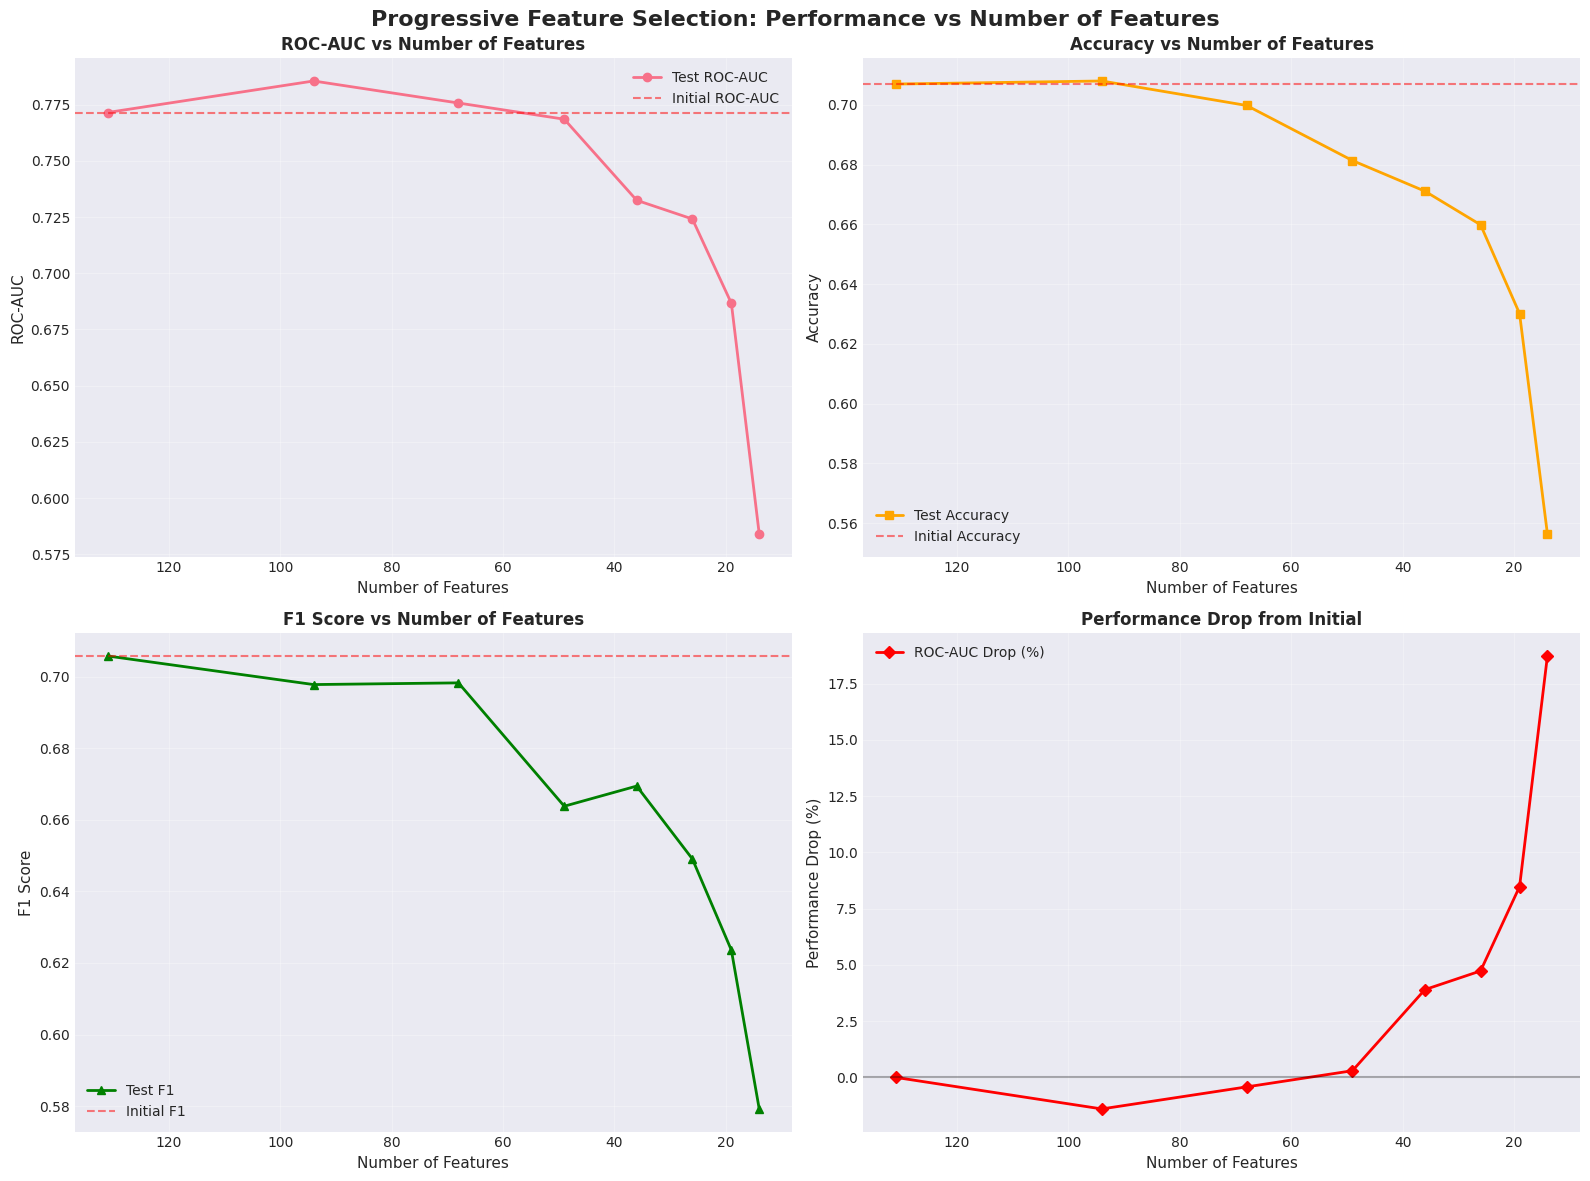

✓ Saved performance plot to: /home/Phenotype and Voice for PD/outputs/progressive_feature_selection/progressive_selection_performance.png


In [11]:
# ============================================================
# Visualization: Performance vs Number of Features
# ============================================================

fig, axes = plt.subplots(2, 2, figsize=(16, 12))
fig.suptitle('Progressive Feature Selection: Performance vs Number of Features', 
             fontsize=16, fontweight='bold')

# Sort by number of features (descending)
results_sorted = results_df.sort_values('n_features', ascending=False)

# 1. ROC-AUC
ax = axes[0, 0]
ax.plot(results_sorted['n_features'], results_sorted['test_roc_auc'], 
        marker='o', linewidth=2, markersize=6, label='Test ROC-AUC')
ax.axhline(y=initial['test_roc_auc'], color='r', linestyle='--', alpha=0.5, label='Initial ROC-AUC')
ax.set_xlabel('Number of Features', fontsize=11)
ax.set_ylabel('ROC-AUC', fontsize=11)
ax.set_title('ROC-AUC vs Number of Features', fontsize=12, fontweight='bold')
ax.legend()
ax.grid(True, alpha=0.3)
ax.invert_xaxis()  # Show decreasing features from left to right

# 2. Accuracy
ax = axes[0, 1]
ax.plot(results_sorted['n_features'], results_sorted['test_accuracy'], 
        marker='s', linewidth=2, markersize=6, label='Test Accuracy', color='orange')
ax.axhline(y=initial['test_accuracy'], color='r', linestyle='--', alpha=0.5, label='Initial Accuracy')
ax.set_xlabel('Number of Features', fontsize=11)
ax.set_ylabel('Accuracy', fontsize=11)
ax.set_title('Accuracy vs Number of Features', fontsize=12, fontweight='bold')
ax.legend()
ax.grid(True, alpha=0.3)
ax.invert_xaxis()

# 3. F1 Score
ax = axes[1, 0]
ax.plot(results_sorted['n_features'], results_sorted['test_f1'], 
        marker='^', linewidth=2, markersize=6, label='Test F1', color='green')
ax.axhline(y=initial['test_f1'], color='r', linestyle='--', alpha=0.5, label='Initial F1')
ax.set_xlabel('Number of Features', fontsize=11)
ax.set_ylabel('F1 Score', fontsize=11)
ax.set_title('F1 Score vs Number of Features', fontsize=12, fontweight='bold')
ax.legend()
ax.grid(True, alpha=0.3)
ax.invert_xaxis()

# 4. Performance drop
ax = axes[1, 1]
initial_auc = initial['test_roc_auc']
auc_drop = (initial_auc - results_sorted['test_roc_auc']) * 100  # Percentage drop
ax.plot(results_sorted['n_features'], auc_drop, 
        marker='D', linewidth=2, markersize=6, label='ROC-AUC Drop (%)', color='red')
ax.axhline(y=0, color='k', linestyle='-', alpha=0.3)
ax.set_xlabel('Number of Features', fontsize=11)
ax.set_ylabel('Performance Drop (%)', fontsize=11)
ax.set_title('Performance Drop from Initial', fontsize=12, fontweight='bold')
ax.legend()
ax.grid(True, alpha=0.3)
ax.invert_xaxis()

plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'progressive_selection_performance.png', dpi=300, bbox_inches='tight')
plt.show()
print(f"✓ Saved performance plot to: {OUTPUT_DIR / 'progressive_selection_performance.png'}")


In [12]:
# ============================================================
# Summary Table
# ============================================================

print("\n" + "=" * 80)
print("PROGRESSIVE FEATURE SELECTION SUMMARY")
print("=" * 80)

summary_cols = ['step', 'n_features', 'test_accuracy', 'test_roc_auc', 'test_f1']
summary_display = results_df[summary_cols].copy()
summary_display = summary_display.sort_values('n_features', ascending=False)

# Format for display
summary_display['test_accuracy'] = summary_display['test_accuracy'].apply(lambda x: f"{x:.4f}")
summary_display['test_roc_auc'] = summary_display['test_roc_auc'].apply(lambda x: f"{x:.4f}")
summary_display['test_f1'] = summary_display['test_f1'].apply(lambda x: f"{x:.4f}")

print("\n" + summary_display.to_string(index=False))
print("=" * 80)

# Save summary
results_df[summary_cols].to_csv(OUTPUT_DIR / 'progressive_selection_summary.csv', index=False)
print(f"\n✓ Saved summary to: {OUTPUT_DIR / 'progressive_selection_summary.csv'}")



PROGRESSIVE FEATURE SELECTION SUMMARY

 step  n_features test_accuracy test_roc_auc test_f1
    1         131        0.7070       0.7714  0.7058
    2          94        0.7080       0.7855  0.6978
    3          68        0.6998       0.7757  0.6982
    4          49        0.6814       0.7685  0.6638
    5          36        0.6711       0.7324  0.6694
    6          26        0.6598       0.7241  0.6490
    7          19        0.6301       0.6866  0.6236
    8          14        0.5564       0.5841  0.5792

✓ Saved summary to: /home/Phenotype and Voice for PD/outputs/progressive_feature_selection/progressive_selection_summary.csv
